In [1]:
from sklearn import datasets
import numpy as np

iris = datasets.load_iris()
X = iris.data[:, [2, 3]]
y = iris.target

In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size= 0.3, random_state= 1, stratify= y
)

# Stratify = y : 전체 데이터 셋에서 각 라벨에 속하는 데이터의 비율이 Training set과 Test set에서 유지되도록 함


In [3]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
sc.fit(X_train)
X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)

In [4]:
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt

def plot_decision_regions(X, y, classifier, test_idx = None, resolution = 0.02):
    markers = ('o', 's', '^', '<', '>')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])
    # ListedColormap은 정해진 몇가지 색살으로 딱딱 끊어지는 이산적인 컬러맵 만들때 사용

    # Set boundary of X1, X2
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    # Grid structure of X1 and X2
    x1_grid = np.arange(x1_min, x1_max, resolution)
    x2_grid = np.arange(x2_min, x2_max, resolution)

    xx1, xx2 = np.meshgrid(x1_grid, x2_grid)

    # To put the grid into model, stick the data
    grid_reshaped = np.array([xx1.ravel(), xx2.ravel()]).T

    # Predict the labels
    lab = classifier.predict(grid_reshaped)
    lab = lab.reshape(xx1.shape)
    
    # draw contour plot
    plt.contourf(xx1, xx2, lab, alpha = 0.3, cmap = cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x = X[y == cl, 0],
                    y = X[y == cl, 1],
                    alpha = 0.8,
                    c = colors[idx],
                    marker = markers[idx],
                    label = f"class {cl}",
                    edgecolors='black')
        
    if test_idx:
        X_test, y_test = X[test_idx, :], y[test_idx]

        plt.scatter(
            X_test[:, 0],
            X_test[:, 1],
            c='none',
            edgecolors='black',
            alpha = 1.0,
            linewidth = 1,
            marker = 'o',
            label = 'Test set'
        )

In [5]:
X_combined_std = np.vstack((X_train_std, X_test_std))
y_combined = np.hstack((y_train, y_test))

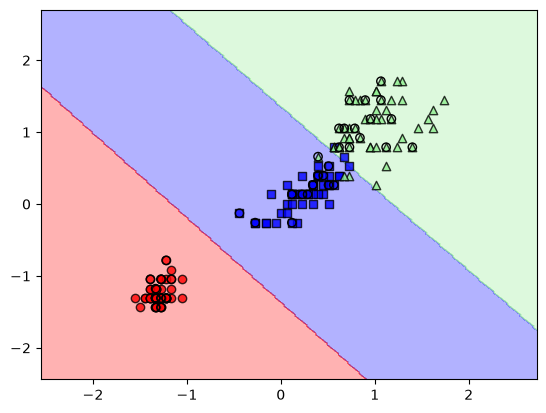

In [7]:
from sklearn.svm import SVC

svm = SVC(kernel = "linear", C = 1.0)
svm.fit(X_train_std, y_train)

plot_decision_regions(X_combined_std, y_combined, classifier=svm, test_idx = range(105, 150))
plt.show()

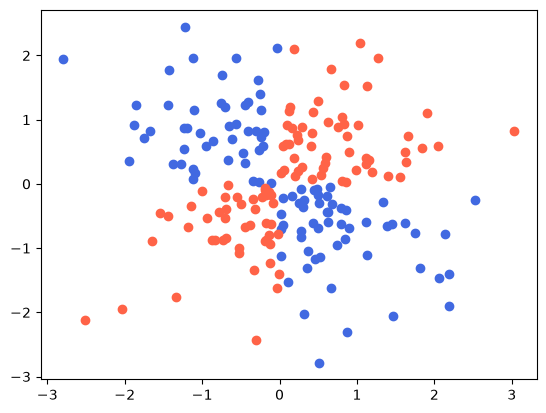

In [9]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(1)
X_xor = np.random.randn(200, 2)
y_xor = np.logical_xor(X_xor[:, 0] > 0, X_xor[:, 1] > 0)
y_xor = np.where(y_xor, 1, 0)

plt.scatter(X_xor[y_xor == 1,0],
            X_xor[y_xor == 1, 1], c = "royalblue")

plt.scatter(X_xor[y_xor == 0,0],
            X_xor[y_xor ==0, 1], c = "tomato")

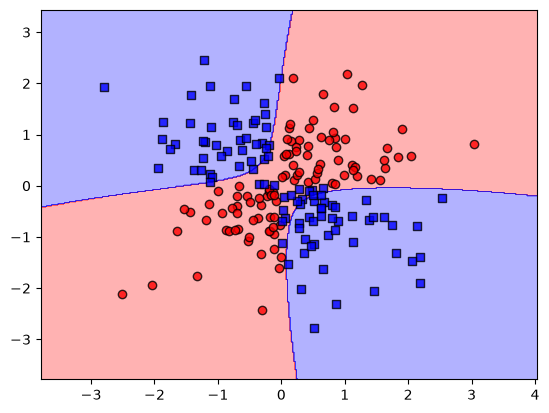

In [10]:
svm = SVC(kernel = 'rbf', random_state=1, gamma=0.1, C=10)
svm.fit(X_xor,y_xor)

plot_decision_regions(X_xor, y_xor, classifier=svm)
plt.show()

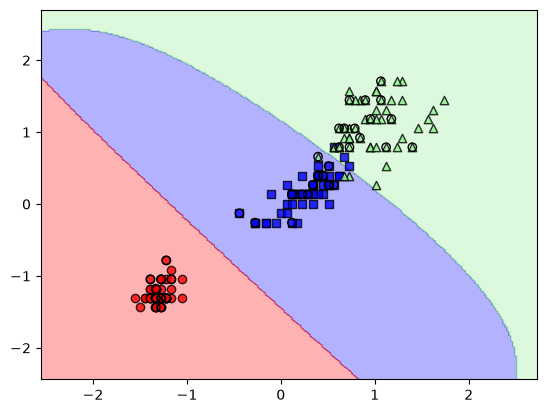

In [11]:
svm = SVC(kernel='rbf', random_state=1, gamma=0.2, C = 1.0)
svm.fit(X_train_std, y_train)
plot_decision_regions(X_combined_std, y_combined, classifier=svm, test_idx=range(105, 150))

plt.show()